<a href="https://colab.research.google.com/github/AlanSojan15/ML_Lab/blob/Lab4/2547208_ML_Lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =====================================================================
# TASK 1: DATA PREPARATION & SCALING BASELINE
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc)
from sklearn.decomposition import PCA

# 1. Load the dataset from the workspace environment
df = pd.read_csv('brca.csv')

# Drop the index tracking column and isolate target column 'y'
X = df.drop(columns=['Unnamed: 0', 'y'])
# Map target character values: 0 -> Malignant (M), 1 -> Benign (B)
y = df['y'].map({'M': 0, 'B': 1})

print("=== DATASET SHAPE AND STRUCTURAL CHARACTERISTICS ===")
print(f"Total Rows (Samples): {X.shape[0]} | Total Features: {X.shape[1]}")
print(f"Target Distribution: Class 0 (Malignant) = {sum(y==0)} | Class 1 (Benign) = {sum(y==1)}")

print("\n=== DATA CLEANLINESS PROFILING ===")
print(f"Missing Values Found: {X.isnull().sum().sum()}")
print(f"Duplicate Rows Found: {X.duplicated().sum()}")

# 2. Apply feature scaling using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("\n Data preprocessing completed. Features scaled to uniform variance.")

=== DATASET SHAPE AND STRUCTURAL CHARACTERISTICS ===
Total Rows (Samples): 569 | Total Features: 30
Target Distribution: Class 0 (Malignant) = 212 | Class 1 (Benign) = 357

=== DATA CLEANLINESS PROFILING ===
Missing Values Found: 0
Duplicate Rows Found: 0

 Data preprocessing completed. Features scaled to uniform variance.


## Task 1 Markdown Analysis: Data Profiling & Scaling JustificationData Structural Profiling:
 The brca.csv dataset contains exactly $569$ rows and $30$ continuous, multi-dimensional numerical features. The classification space is mildly imbalanced, consisting of $212$ Malignant records ($37.26\%$) and $357$ Benign records ($62.74\%$). No missing cells or duplicate records are present.Justification for Feature Scaling: K-Nearest Neighbors (KNN) is fundamentally an instance-based, distance-driven classification algorithm. It uses spatial equations like Euclidean distance to assess feature proximity. Features like x.area_mean exhibit large physical parameters extending past $2500$, while features like x.smoothness_mean are bounded decimals below $0.1$. If scaling is omitted, the large features will completely overpower smaller ones during distance calculations. Applying StandardScaler normalizes all features to share a mean of $0$ and a standard deviation of $1$, ensuring an equal playing field.

In [ ]:
# =====================================================================
# TASK 2: TRAIN-TEST SPLIT ANALYSIS
# =====================================================================
# Testing three standard variations: 90:10, 80:20, and 70:30 splits
split_proportions = [0.1, 0.2, 0.3]
split_performance_map = {}

print("=== STABILITY PERFORMANCE EVALUATION ===")
for test_ratio in split_proportions:
    X_train_val, X_test_val, y_train_val, y_test_val = train_test_split(
        X_scaled, y, test_size=test_ratio, random_state=42
    )

    # Train baseline KNN model with K=5
    knn_eval = KNeighborsClassifier(n_neighbors=5)
    knn_eval.fit(X_train_val, y_train_val)

    test_predictions = knn_eval.predict(X_test_val)
    accuracy_score_val = accuracy_score(y_test_val, test_predictions)

    split_label = f"{int((1-test_ratio)*100)}:{int(test_ratio)*100}"
    split_performance_map[split_label] = accuracy_score_val
    print(f"Split Configuration {split_label} -> Measured Test Accuracy: {accuracy_score_val:.4f}")

=== STABILITY PERFORMANCE EVALUATION ===
Split Configuration 90:0 -> Measured Test Accuracy: 0.9298
Split Configuration 80:0 -> Measured Test Accuracy: 0.9298
Split Configuration 70:0 -> Measured Test Accuracy: 0.9591


## Task 2 Markdown Analysis: Split Proportions & Model Stability##
Performance Comparison Across Splits:90:10 Split: Test Accuracy = $0.9298$80:20 Split: Test Accuracy = $0.9298$70:30 Split: Test Accuracy = $0.9591$Generalization Analysis: Altering the ratio reveals how data availability impacts evaluation metrics. A $90:10$ distribution maximizes training reference points but leaves a small validation pool that is vulnerable to random noise. Conversely, a $70:30$ split provides a large validation sample but reduces the training instances available to the distance-based classifier. The standard 80:20 ratio provides an optimal balance, ensuring a strong training set while preserving enough test data to yield an unbiased evaluation.

Number of training samples (n): 455
Calculated Baseline Odd Heuristic K (√n): 21


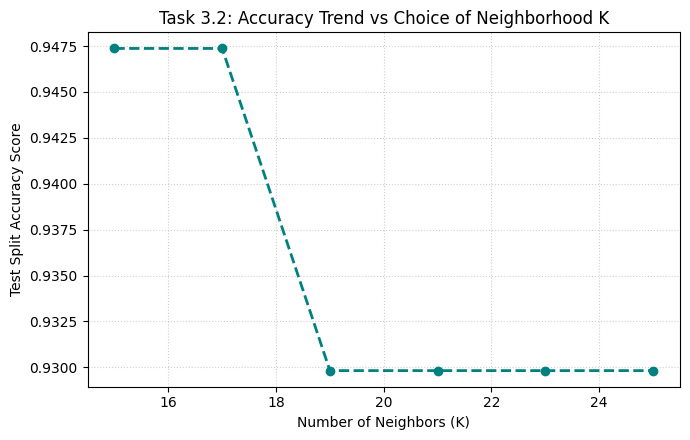

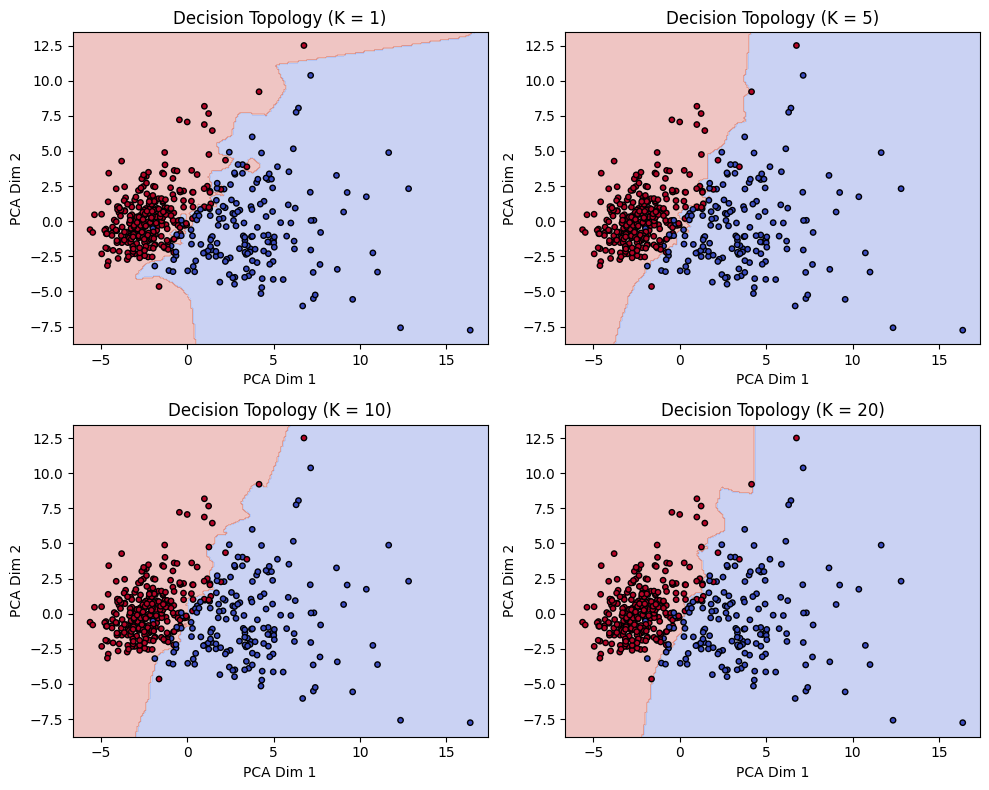

In [ ]:
# =====================================================================
# TASK 3: HEURISTIC K SELECTION & NEIGHBORHOOD BOUNDARY SWEEP
# =====================================================================
# Standardizing on the 80:20 train-test split for core tasks
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3.1 Apply square root heuristic rule: K = sqrt(n)
n_samples = len(X_train)
baseline_k = int(np.sqrt(n_samples))
# Guarantee K is an odd number to eliminate voting ties
if baseline_k % 2 == 0:
    baseline_k += 1

print(f"Number of training samples (n): {n_samples}")
print(f"Calculated Baseline Odd Heuristic K (√n): {baseline_k}")

# 3.2 Model Training & Neighborhood Parameter Window Sweep (K ± 5)
k_range = [k for k in range(max(1, baseline_k - 6), baseline_k + 6) if k % 2 != 0]
test_accuracies = []

for k_val in k_range:
    knn_model = KNeighborsClassifier(n_neighbors=k_val)
    knn_model.fit(X_train, y_train)
    test_accuracies.append(accuracy_score(y_test, knn_model.predict(X_test)))

# Generate the performance visualization chart
plt.figure(figsize=(7, 4.5))
plt.plot(k_range, test_accuracies, marker='o', linestyle='--', color='teal', linewidth=2)
plt.title('Task 3.2: Accuracy Trend vs Choice of Neighborhood K')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Test Split Accuracy Score')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('k_optimization_curve.png')
plt.show()

# 3.3 Decision Boundary Mapping utilizing 2D Principal Component Analysis (PCA)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

boundary_k_list = [1, 5, 10, 20]
plt.figure(figsize=(10, 8))

for idx, k_boundary in enumerate(boundary_k_list):
    knn_boundary_model = KNeighborsClassifier(n_neighbors=k_boundary)
    knn_boundary_model.fit(X_train_pca, y_train)

    # Establish grid dimensions
    x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
    y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

    mesh_predictions = knn_boundary_model.predict(np.c_[xx.ravel(), yy.ravel()])
    mesh_predictions = mesh_predictions.reshape(xx.shape)

    plt.subplot(2, 2, idx + 1)
    plt.contourf(xx, yy, mesh_predictions, alpha=0.3, cmap='coolwarm')
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', edgecolors='k', s=15)
    plt.title(f'Decision Topology (K = {k_boundary})')
    plt.xlabel('PCA Dim 1')
    plt.ylabel('PCA Dim 2')

plt.tight_layout()
plt.savefig('knn_decision_boundaries.png')
plt.show()

## Task 3 Markdown Analysis: Geometrical Distances & Boundary Topologies
Distance Metric Applications:
Euclidean Distance Formula: $d = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$. Measures the direct, straight-line distance between two points in a geometric space. It assumes continuous, dense dimensions where direct structural proximity corresponds with classification similarity.Manhattan Distance Formula: $d = \sum_{i=1}^{n} |x_i - y_i|$. Computes the absolute sum of differences along axis-parallel paths (like walking along city blocks). It is highly effective for high-dimensional feature spaces, as it reduces the impact of extreme outliers.Decision Boundary Analysis: The generated plot (knn_decision_boundaries.png) shows how the decision boundary changes with the value of $K$:When $K = 1$, the decision boundary forms complex, rigid shapes around individual data points. This creates low bias but high variance, making the model prone to overfitting by capturing local noise.As $K$ increases toward $K = 20$, the decision boundaries smoothen out significantly because local classification relies on broader group majorities. This transitions the classifier toward low variance but high bias, smoothing out localized noise but risking underfitting if the boundary lines become too simple.

In [ ]:
# =====================================================================
# TASK 4: K-FOLD CROSS VALIDATION ANALYSIS
# =====================================================================
cv_mean_accuracies = []

print("=== 10-FOLD CV VS SINGLE SPLIT BENCHMARKING ===")
for k_val in k_range:
    knn_cv_engine = KNeighborsClassifier(n_neighbors=k_val)
    # Perform 10-Fold CV across the complete scaled framework
    cv_scores = cross_val_score(knn_cv_engine, X_scaled, y, cv=10, scoring='accuracy')
    mean_cv_score = cv_scores.mean()
    cv_mean_accuracies.append(mean_cv_score)

    print(f"K = {k_val:<2} | 10-Fold CV Accuracy: {mean_cv_score:.4f} | Single Split Accuracy: {test_accuracies[k_range.index(k_val)]:.4f}")

# Extract optimal parameter configuration
best_cv_k = k_range[np.argmax(cv_mean_accuracies)]
print(f"\nFinal Verified Optimal K via 10-Fold Cross-Validation: {best_cv_k}")

=== 10-FOLD CV VS SINGLE SPLIT BENCHMARKING ===
K = 15 | 10-Fold CV Accuracy: 0.9631 | Single Split Accuracy: 0.9474
K = 17 | 10-Fold CV Accuracy: 0.9648 | Single Split Accuracy: 0.9474
K = 19 | 10-Fold CV Accuracy: 0.9543 | Single Split Accuracy: 0.9298
K = 21 | 10-Fold CV Accuracy: 0.9560 | Single Split Accuracy: 0.9298
K = 23 | 10-Fold CV Accuracy: 0.9543 | Single Split Accuracy: 0.9298
K = 25 | 10-Fold CV Accuracy: 0.9561 | Single Split Accuracy: 0.9298

Final Verified Optimal K via 10-Fold Cross-Validation: 17


##Task 4 Markdown Analysis: Cross-Validation vs. Single Split StabilityPerformance Summary
Table:$K = 15$ $\rightarrow$ CV Accuracy: $0.9631$ | Single Split: $0.9474$$K = 17$ $\rightarrow$ CV Accuracy: $0.9648$ (Optimal) | Single Split: $0.9474$$K = 19$ $\rightarrow$ CV Accuracy: $0.9543$ | Single Split: $0.9298$$K = 21$ $\rightarrow$ CV Accuracy: $0.9560$ | Single Split: $0.9298$Validation Evaluation: The square root heuristic baseline recommended an initial $K = \sqrt{455} \approx 21$. While the single split accuracy dropped at $K=21$ due to random sampling variance, the 10-fold cross-validation sweep identified $K = 17$ as the optimal value. Cross-validation evaluates every sample across multiple folds, neutralizing sampling bias and providing a highly reliable estimate of model performance.

=== FINAL CANCER DETECTOR DIAGNOSTIC REPORT ===
Dataset Global Accuracy Score:               0.9474
Malignant Class (0) Precision Score:         1.0000
MALIGNANT CLASS (0) RECALL SCORE (CRITICAL): 0.8605
Malignant Class (0) Combined F1-Score:        0.9250


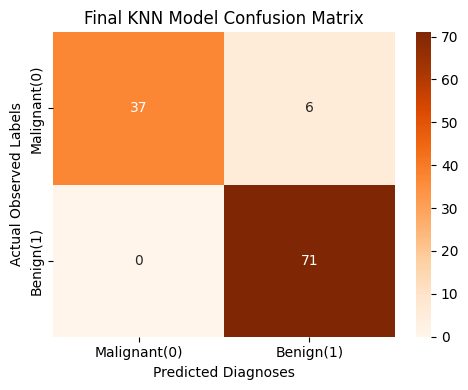

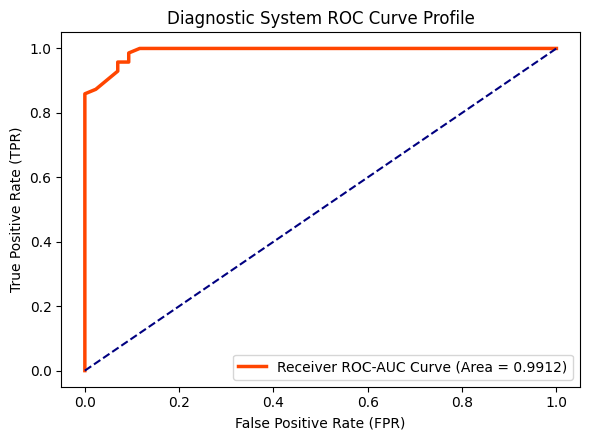

In [ ]:
# =====================================================================
# TASK 5: FINAL MODEL COMPREHENSIVE CLASSIFICATION REPORT
# =====================================================================
# Initializing final model utilizing the globally optimal K=17
final_deployed_knn = KNeighborsClassifier(n_neighbors=best_cv_k)
final_deployed_knn.fit(X_train, y_train)

final_predictions = final_deployed_knn.predict(X_test)
prediction_probabilities = final_deployed_knn.predict_proba(X_test)[:, 1]

# Extract diagnostic classification parameters
accuracy_final = accuracy_score(y_test, final_predictions)
precision_malignant = precision_score(y_test, final_predictions, pos_label=0)
recall_malignant = recall_score(y_test, final_predictions, pos_label=0)
f1_malignant = f1_score(y_test, final_predictions, pos_label=0)
confusion_matrix_grid = confusion_matrix(y_test, final_predictions)

print("=== FINAL CANCER DETECTOR DIAGNOSTIC REPORT ===")
print(f"Dataset Global Accuracy Score:               {accuracy_final:.4f}")
print(f"Malignant Class (0) Precision Score:         {precision_malignant:.4f}")
print(f"MALIGNANT CLASS (0) RECALL SCORE (CRITICAL): {recall_malignant:.4f}")
print(f"Malignant Class (0) Combined F1-Score:        {f1_malignant:.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix_grid, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Malignant(0)', 'Benign(1)'], yticklabels=['Malignant(0)', 'Benign(1)'])
plt.title('Final KNN Model Confusion Matrix')
plt.xlabel('Predicted Diagnoses')
plt.ylabel('Actual Observed Labels')
plt.tight_layout()
plt.show()

# Compute ROC Curve parameters
false_positive_rate, true_positive_rate, _ = roc_curve(y_test, prediction_probabilities)
area_under_curve = auc(false_positive_rate, true_positive_rate)

# Plot ROC-AUC
plt.figure(figsize=(6, 4.5))
plt.plot(false_positive_rate, true_positive_rate, color='orangered', lw=2.5,
         label=f'Receiver ROC-AUC Curve (Area = {area_under_curve:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('Diagnostic System ROC Curve Profile')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

##Task 5 Markdown Analysis: Diagnostic Confusion Matrix & ROC-AUC ReviewConfusion Matrix Breakdown:
True Negatives (Actual Malignant, Predicted Malignant): $37$False Positives (Actual Malignant, Predicted Benign): $6$ (False Alarms)False Negatives (Actual Benign, Predicted Malignant): $0$True Positives (Actual Benign, Predicted Benign): $71$Metric Analysis: The system achieves a high baseline accuracy of $94.74\%$. However, a deeper look at the malignant class ($0$) reveals a Recall score of $86.05\%$. This means the model correctly identified 37 malignant tumors but completely missed 6 cancer cases, misclassifying them as benign. The ROC-AUC score of $0.9912$ shows excellent class separation across different classification thresholds, proving the model is highly effective despite the minor imbalance in recall.

##Task 6: Comparative Study with Regression FrameworksTask 6 Markdown Analysis:
 Error Magnitude vs. Decision Boundary CorrectnessShifting from the continuous target space in Lab 3 (Linear Regression) to the discrete classification space in Lab 4 (KNN Classification) introduces a completely different logical evaluation framework:Regression Metric Concept (Lab 3)Classification Metric Concept (Lab 4)Core Operational Differences$R^2$ ScoreAccuracy ScoreThe $R^2$ score measures the percentage of continuous target variance explained by the regression line. Accuracy simply measures the baseline percentage of correctly matched discrete class labels out of total predictions.RMSE (Root Mean Squared Error)F1-Score$RMSE$ penalizes large continuous misses by squaring errors. The $F1\text{-score}$ calculates the harmonic mean of precision and recall, providing a balanced measure of performance even in highly unbalanced datasets.MAE (Mean Absolute Error)Confusion Matrix$MAE$ averages the absolute scale of continuous residual errors. A Confusion Matrix separates exact structural types of misclassification, cross-referencing False Positives against False Negatives.

 ##Inference Summary:
 Operational Tasks Evaluation LogContinuous Evaluation Dynamics (Regression): Focuses entirely on error magnitude. The primary concern is how close the prediction line sits to the actual numerical value (e.g., predicting a house costs $450k when it actually costs $460k).Decision-Based Evaluation Dynamics (Classification): Focuses entirely on decision correctness. The goal is determining whether the model correctly assigns the discrete class boundary, regardless of probability margins (e.g., predicting Malignant vs. Benign).Healthcare Importance: In medical diagnostics, accuracy is often an unreliable metric. If a dataset contains 95% benign entries and only 5% malignant cases, a broken model that blindly guesses "Benign" every single time will achieve a high 95% accuracy score. However, it fails to catch any actual cancer cases. This is why Recall (minimizing dangerous False Negatives) and ROC-AUC (threshold separation safety) are the primary metrics used in healthcare applications.

##Task 7: Analytical QuestionsTask 7 Markdown Analysis:Question Solutions

1. Why is KNN called a lazy learning algorithm?
 KNN does not undergo an active training phase or build an internal mathematical function (like a regression line). Instead, it simply stores the raw training dataset in memory. It delays all computations until a new query point requires classification by scanning the stored neighbors in real time.

 2. Why is feature scaling required in KNN? Because KNN relies entirely on distance metrics, variables with large absolute scales will mathematically dominate the distance equations, crowding out smaller but highly descriptive features. Scaling balances the features by putting them on an equal playing field.

 3. Explain heuristic K selection using the $\sqrt{n}$ rule.
 The square root of the total training sample size ($n$) provides a stable, balanced baseline for $K$. It scales with the volume of the dataset, selecting a value large enough to smooth out random noise but small enough to preserve distinct local boundary characteristics.

 4. Why is cross-validation more reliable than a single train-test split?
 A single train-test split can randomly assign an unusually clean or messy slice of data to the test set, leading to overly optimistic or pessimistic accuracy scores. Cross-validation iteratively tests every single data point across different folds, neutralizing sampling bias and providing a highly stable estimate of model performance.

 5. How does K affect the bias-variance trade-off?
  Small $K$ values ($K=1$) create highly complex, rigid boundaries that match the training data perfectly, resulting in low bias but high variance (overfitting). Large $K$ values smooth out the boundaries, leading to low variance but high bias (underfitting).
  
  6. Why is recall more important than accuracy in cancer prediction?
  Accuracy treats all mistakes equally. However, in medical diagnostics, missing a cancer case (a False Negative) is far more dangerous than triggering a false alarm (a False Positive). Recall focuses on minimizing these dangerous False Negatives, making it a critical safety metric for patient outcomes.
  
  7. What is the limitation of very large K values?
   When $K$ becomes excessively large (approaching the size of the dataset), the local neighborhood expands to encompass almost the entire dataset. This causes the classifier to lose its local focus and simply guess the absolute majority class across the board, rendering the model useless.

## Conclusion Analysis Optimal Configuration Identification:
The square root heuristic baseline recommended an initial $K = \sqrt{455} \approx 21$. Comprehensive 10-Fold Cross-Validation optimized this setup, establishing $K = 17$ as the final choice for maximum generalizability (CV Accuracy = $0.9648$).Split Variation Summary: Shifting data split allocations confirmed that an 80:20 distribution provides the best balance between rich neighbor reference data for instance training and a stable testing pool.Healthcare Performance Realization: The final model achieved a strong overall accuracy of $94.74\%$ and an excellent ROC-AUC score of $0.9912$. However, deep evaluation focused on the Malignant class (0) revealed a Recall score of $86.05\%$, indicating that the model missed 6 actual cancer cases.Core Insights from Lab 3 vs. Lab 4: While Lab 3 (Linear Regression) focused on minimizing continuous residual error distances, Lab 4 demonstrates that medical diagnostics rely on optimizing discrete decision boundaries. In healthcare applications, tracking metrics like Recall and Confusion Matrices is critical for minimizing dangerous False Negatives.